In [54]:
import os
import rasterio
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime

import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import xarray as xr

# Exploration of the PRISM climate dataset

In [55]:
ppt_dir = "../datasets/climate_dataset/prism_ppt_us_25m_2020_avg_30y"
tmin_dir = "../datasets/climate_dataset/prism_tmin_us_25m_2020_avg_30y"
tmax_dir = "../datasets/climate_dataset/prism_tmax_us_25m_2020_avg_30y"

## Visualizations

In [22]:
def plot_raster(path, title, cmap="viridis", units=""):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata

        # Mask no-data values
        if nodata is not None:
            data[data == nodata] = np.nan

        # plt.figure(figsize=(8, 6))
        img = plt.imshow(data, cmap=cmap)
        plt.colorbar(img, label=units)
        plt.title(title)
        plt.axis("off")

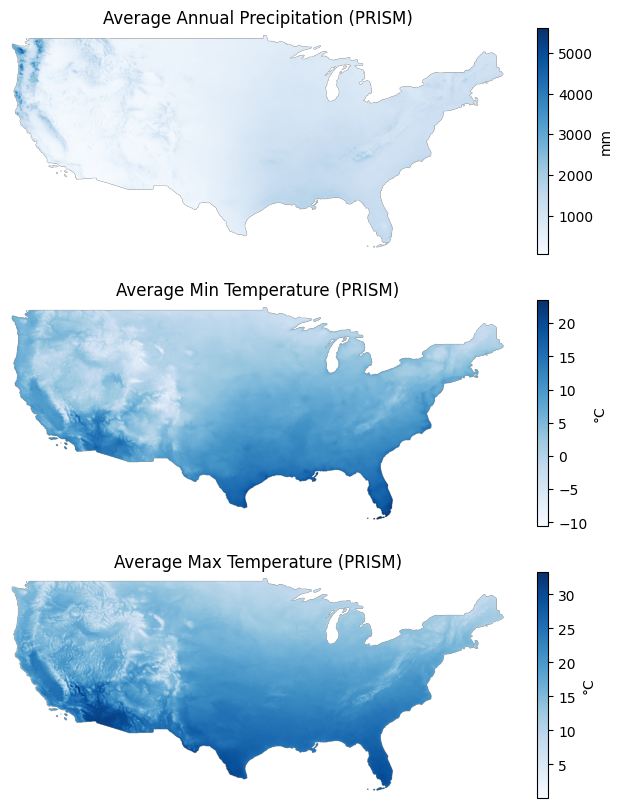

In [24]:
# plot the maps
plt.subplots(3, 1, figsize=(8, 10))
ax = plt.subplot(3, 1, 1)
plot_raster(
    path=ppt_dir + "/prism_ppt_us_25m_2020_avg_30y.tif",
    title="Average Annual Precipitation (PRISM)",
    cmap="Blues",
    units="mm"
)
ax = plt.subplot(3, 1, 2)
plot_raster(
    path=tmin_dir + "/prism_tmin_us_25m_2020_avg_30y.tif",
    title="Average Min Temperature (PRISM)",
    cmap="Blues",
    units="°C"
)
ax = plt.subplot(3, 1, 3)
plot_raster(
    path=tmax_dir + "/prism_tmax_us_25m_2020_avg_30y.tif",
    title="Average Max Temperature (PRISM)",
    cmap="Blues",
    units="°C"
)

plt.show()


## Climate data from coords

In [3]:
def extract_idw_16(
    raster_path,
    lon,
    lat,
    power=2
):
    """
    Extract an inverse-distance-weighted interpolation
    using the closest 16 raster cells (4x4 window).

    Parameters
    ----------
    raster_path : str
        Path to GeoTIFF raster (PRISM precip, tmin, tmax)
    lon, lat : float
        Longitude and latitude (EPSG:4326)
    power : float
        IDW power parameter (2 is standard)

    Returns
    -------
    float or np.nan
    """

    with rasterio.open(raster_path) as src:
        # Coordinate transformer (lat/lon -> raster CRS)
        if src.crs.to_string() != "EPSG:4326":
            transformer = Transformer.from_crs(
                "EPSG:4326", src.crs, always_xy=True
            )
            x, y = transformer.transform(lon, lat)
        else:
            x, y = lon, lat

        # Find nearest pixel
        row, col = rowcol(src.transform, x, y)

        # Define 4x4 window centered on nearest pixel
        half = 2
        rows = np.arange(row - half + 1, row + half + 1)
        cols = np.arange(col - half + 1, col + half + 1)

        # Clip to raster bounds
        rows = rows[(rows >= 0) & (rows < src.height)]
        cols = cols[(cols >= 0) & (cols < src.width)]

        values = []
        distances = []

        for r in rows:
            for c in cols:
                val = src.read(1, window=((r, r + 1), (c, c + 1)))[0, 0]

                if val == src.nodata:
                    continue

                # Center of the pixel
                px, py = src.transform * (c + 0.5, r + 0.5)

                d = np.sqrt((px - x) ** 2 + (py - y) ** 2)

                # If the point falls exactly on a grid cell
                if d == 0:
                    return float(val)

                values.append(val)
                distances.append(d)

        if len(values) == 0:
            return np.nan

        values = np.array(values)
        distances = np.array(distances)

        weights = 1 / distances ** power
        return float(np.sum(weights * values) / np.sum(weights))

In [4]:
def extract_idw_16_cached(
    src,
    lon,
    lat,
    power=2
):
    # Coordinate transformer (lat/lon -> raster CRS)
    if src.crs.to_string() != "EPSG:4326":
        transformer = Transformer.from_crs(
            "EPSG:4326", src.crs, always_xy=True
        )
        x, y = transformer.transform(lon, lat)
    else:
        x, y = lon, lat

    # Find nearest pixel
    row, col = rowcol(src.transform, x, y)

    # Define 4x4 window centered on nearest pixel
    half = 2
    rows = np.arange(row - half + 1, row + half + 1)
    cols = np.arange(col - half + 1, col + half + 1)

    # Clip to raster bounds
    rows = rows[(rows >= 0) & (rows < src.height)]
    cols = cols[(cols >= 0) & (cols < src.width)]

    values = []
    distances = []

    for r in rows:
        for c in cols:
            val = src.read(1, window=((r, r + 1), (c, c + 1)))[0, 0]

            if val == src.nodata:
                continue

            # Center of the pixel
            px, py = src.transform * (c + 0.5, r + 0.5)

            d = np.sqrt((px - x) ** 2 + (py - y) ** 2)

            # If the point falls exactly on a grid cell
            if d == 0:
                return float(val)

            values.append(val)
            distances.append(d)

    if len(values) == 0:
        return np.nan

    values = np.array(values)
    distances = np.array(distances)

    weights = 1 / distances ** power
    return float(np.sum(weights * values) / np.sum(weights))

In [5]:
precip = extract_idw_16(
    ppt_dir + "/prism_ppt_us_25m_2020_avg_30y.tif",
    lon=-120.75,
    lat=38.55
)

tmin = extract_idw_16(
    tmin_dir + "/prism_tmin_us_25m_2020_avg_30y.tif",
    lon=-120.75,
    lat=38.55
)

tmax = extract_idw_16(
    tmax_dir + "/prism_tmax_us_25m_2020_avg_30y.tif",
    lon=-120.75,
    lat=38.55
)

print(f"Precipitation: {precip} mm")
print(f"Min Temperature: {tmin} °C")
print(f"Max Temperature: {tmax} °C")

Precipitation: 890.7437429031711 mm
Min Temperature: 8.023748463889095 °C
Max Temperature: 21.53991981271672 °C


In [6]:
def haversine(lon1, lat1, lon2, lat2):
    """
    Compute great-circle distance (km)
    """
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


def idw(values, distances, power=2):
    weights = 1 / np.power(distances, power)
    return np.sum(weights * values) / np.sum(weights)


In [7]:
BASE = "https://opendap.earthdata.nasa.gov/thredds/dodsC/ornldaac/2130"

def open_daymet(year, variable):
    """
    Open Daymet annual dataset remotely
    variable: 'prcp', 'tmin', 'tmax'
    """
    url = f"{BASE}/daymet_v4_{variable}_annavg_{year}.nc"
    return xr.open_dataset(url)


In [8]:
def sample_year_variable(
    lat, lon, year, variable, k=16, power=2
):
    ds = open_daymet(year, variable)

    lats = ds["lat"].values
    lons = ds["lon"].values
    data = ds[variable].values

    # Flatten grid
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    flat_lats = lat_grid.ravel()
    flat_lons = lon_grid.ravel()
    flat_data = data.ravel()

    # Compute distances
    distances = haversine(
        lon, lat, flat_lons, flat_lats
    )

    # Select k nearest neighbors
    idx = np.argsort(distances)[:k]
    nearest_values = flat_data[idx]
    nearest_distances = distances[idx]

    return idw(nearest_values, nearest_distances, power)


In [9]:
def climate_features_daymet(
    lat,
    lon,
    n_years=10,
    k=16,
    power=2,
    end_year=None
):
    if end_year is None:
        end_year = datetime.now().year - 1

    years = range(end_year - n_years + 1, end_year + 1)

    results = {
        "prcp": [],
        "tmin": [],
        "tmax": []
    }

    for year in years:
        for var in results.keys():
            value = sample_year_variable(
                lat, lon, year, var, k=k, power=power
            )
            results[var].append(value)

    return {
        "prcp_avg": np.mean(results["prcp"]),
        "tmin_avg": np.mean(results["tmin"]),
        "tmax_avg": np.mean(results["tmax"]),
    }


In [10]:
lat = 21.3069      # Honolulu
lon = -157.8583

features = climate_features_daymet(
    lat,
    lon,
    n_years=10,
    k=16,
    power=2
)

print(features)


OSError: [Errno -77] NetCDF: Access failure: 'https://opendap.earthdata.nasa.gov/thredds/dodsC/ornldaac/2130/daymet_v4_prcp_annavg_2016.nc'

# Exploration of the ERA5-Land data

## Download dataset

In [52]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-land-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        # 'variable': 'total_precipitation',
        'variable': '2m_temperature',
        'year': [
            '2000','2010','2020',
        ],
        'month': [
            '01', '02', '03',
            '04', '05', '06',
            '07', '08', '09',
            '10', '11', '12',
        ],
        'time': '00:00',
        'format': 'grib',
    },
    '../datasets/climate_dataset_ext/era5_temp.grib.zip')


2026-02-04 11:02:49,348 INFO Request ID is cf7b31ab-318c-495c-a677-085d07b87180
2026-02-04 11:02:49,437 INFO status has been updated to accepted
2026-02-04 11:02:58,302 INFO status has been updated to running
2026-02-04 11:03:22,671 INFO status has been updated to successful


a8d94a0bf1588c6a38fa4584df2ebcc3.zip:   0%|          | 0.00/131M [00:00<?, ?B/s]

'../datasets/climate_dataset_ext/era5_temp.grib.zip'

In [16]:
precip_dir = "../datasets/climate_dataset_ext/era5_precip.grib"
temp_dir = "../datasets/climate_dataset_ext/era5_temp.grib"

## Compute climate averages from coords

In [17]:
def average_annual_precip_4x4(grib_path, lat, lon):
    if isinstance(grib_path, str):
        ds = xr.open_dataset(
            grib_path,
            engine="cfgrib",
            filter_by_keys={'stepType': 'avgas', 'shortName': 'tp'}
        )
    else :
        ds = grib_path

    tp = ds["tp"]

    # Fix longitude convention
    if lon < 0 and tp.longitude.max() > 180:
        lon = lon % 360

    nearest = tp.sel(latitude=lat, longitude=lon, method="nearest")
    lat0 = nearest.latitude.item()
    lon0 = nearest.longitude.item()

    lat_idx = int(np.where(tp.latitude.values == lat0)[0][0])
    lon_idx = int(np.where(tp.longitude.values == lon0)[0][0])

    neighborhood = tp.isel(
        latitude=slice(lat_idx-1, lat_idx+3),
        longitude=slice(lon_idx-1, lon_idx+3)
    )

    # Spatial mean
    spatial_mean = neighborhood.mean(dim=("latitude", "longitude"))

    # ---- FIX: scale by days in month ----
    days_in_month = spatial_mean["time"].dt.days_in_month
    monthly_total = spatial_mean * days_in_month

    # Annual total
    annual = monthly_total.groupby("time.year").sum()

    # Mean across years
    mean_annual_m = annual.mean().item()

    # meters → millimeters
    return mean_annual_m * 1000

In [18]:
def average_annual_tmin_4x4(grib_path, lat, lon):
    if isinstance(grib_path, str):
        ds = xr.open_dataset(
            grib_path,
            engine="cfgrib",
        )
    else :
        ds = grib_path

    t2m = ds["t2m"]  # (time, latitude, longitude) in Kelvin

    if lon < 0 and t2m.longitude.max() > 180:
        lon = lon % 360

    nearest = t2m.sel(latitude=lat, longitude=lon, method="nearest")

    lat0 = nearest.latitude.item()
    lon0 = nearest.longitude.item()

    lat_idx = int(np.where(t2m.latitude.values == lat0)[0][0])
    lon_idx = int(np.where(t2m.longitude.values == lon0)[0][0])

    lat_slice = slice(lat_idx - 1, lat_idx + 3)
    lon_slice = slice(lon_idx - 1, lon_idx + 3)

    neighborhood = t2m.isel(
        latitude=lat_slice,
        longitude=lon_slice
    )

    # Spatial mean
    spatial_mean = neighborhood.mean(dim=("latitude", "longitude"))

    # Monthly → annual minimum
    annual_min = spatial_mean.groupby("time.year").min(dim="time")

    # Mean across years
    mean_annual_min_k = annual_min.mean().item()

    # Kelvin → Celsius
    mean_annual_min_c = mean_annual_min_k - 273.15

    return mean_annual_min_c

In [19]:
def average_annual_tmax_4x4(grib_path, lat, lon):
    if isinstance(grib_path, str):
        ds = xr.open_dataset(
            grib_path,
            engine="cfgrib",
        )
    else :
        ds = grib_path

    t2m = ds["t2m"]

    if lon < 0 and t2m.longitude.max() > 180:
        lon = lon % 360

    nearest = t2m.sel(latitude=lat, longitude=lon, method="nearest")

    lat0 = nearest.latitude.item()
    lon0 = nearest.longitude.item()

    lat_idx = int(np.where(t2m.latitude.values == lat0)[0][0])
    lon_idx = int(np.where(t2m.longitude.values == lon0)[0][0])

    lat_slice = slice(lat_idx - 1, lat_idx + 3)
    lon_slice = slice(lon_idx - 1, lon_idx + 3)

    neighborhood = t2m.isel(
        latitude=lat_slice,
        longitude=lon_slice
    )

    # Spatial mean
    spatial_mean = neighborhood.mean(dim=("latitude", "longitude"))

    # Monthly → annual maximum
    annual_max = spatial_mean.groupby("time.year").max(dim="time")

    # Mean across years
    mean_annual_max_k = annual_max.mean().item()

    # Kelvin → Celsius
    mean_annual_max_c = mean_annual_max_k - 273.15

    return mean_annual_max_c


In [20]:
lat=37.52
lon=-77.32

p = average_annual_precip_4x4(precip_dir, lat,lon)
tmin = average_annual_tmin_4x4(temp_dir, lat, lon)
tmax = average_annual_tmax_4x4(temp_dir, lat, lon)

print(f"Location: lat: {lat:.4f}, lon: {lon:.4f}")
print(f"Average precipitation: {p:.2f} mm")
print(f"Tmin: {tmin:.2f} °C")
print(f"Tmax: {tmax:.2f} °C")


Location: lat: 37.5200, lon: -77.3200
Average precipitation: 1032.18 mm
Tmin: 2.31 °C
Tmax: 26.56 °C


# Add feats to the dataset

In [56]:
precip_ds = xr.open_dataset(
    precip_dir,
    engine="cfgrib",
    filter_by_keys={'stepType': 'avgas', 'shortName': 'tp'}
)
tmin_ds = xr.open_dataset(
    temp_dir,
    engine="cfgrib",
)
tmax_ds = xr.open_dataset(
    temp_dir,
    engine="cfgrib",
)

In [57]:
def get_precipitation_data(lat, lon, src):
    precip = extract_idw_16_cached(src,lon=lon,lat=lat)
    if precip is None or np.isnan(precip):
        precip = average_annual_precip_4x4(precip_ds, lat,lon)
    if precip is None:
        return np.nan
    return precip

def get_min_temperature_data(lat, lon, src):
    tmin = extract_idw_16_cached(src,lon=lon,lat=lat)
    if tmin is None or np.isnan(tmin):
        tmin = average_annual_tmin_4x4(tmin_ds, lat,lon)
    if tmin is None:
        return np.nan
    return tmin

def get_max_temperature_data(lat, lon, src):
    tmax = extract_idw_16_cached(src,lon=lon,lat=lat)
    if tmax is None or np.isnan(tmax):
        tmax = average_annual_tmax_4x4(tmax_ds, lat,lon)
    if tmax is None:
        return np.nan
    return tmax

#### run once

In [24]:
data_dir = Path('../datasets\\')

In [30]:
# Define paths to the storm events CSV files
files = [
    data_dir / 'StormEvents_details-ftp_v1.0_d2016_c20250818.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2017_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2018_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2019_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2020_c20251118.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2021_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2022_c20250721.csv',
]

# Load datasets
print("Loading datasets...")
df_list = []
for file in files:
    # print(f"  Loading {file.name}...")
    df = pd.read_csv(file)
    # print(f"    Shape: {df.shape}")
    df_list.append(df)

# Concatenate the datasets
df = pd.concat(df_list, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")

Loading datasets...

Combined dataset shape: (436146, 51)


In [ ]:
df.drop(columns=[col for col in df.columns if col not in ['INDEX', 'BEGIN_LAT', 'BEGIN_LON']], inplace=True)
df.head()

,BEGIN_LAT,BEGIN_LON
0,34.94,-81.03
1,35.01,-80.93
2,35.64,-82.14
3,35.65,-84.18
4,35.87,-83.77


In [28]:
loc_df = df[['BEGIN_LAT', 'BEGIN_LON']].drop_duplicates().reset_index(drop=True)
loc_df.dropna(subset=['BEGIN_LAT', 'BEGIN_LON'], inplace=True)

In [36]:
# reduce the float precision of lat/lon to 1 decimal places
loc_df['BEGIN_LAT'] = loc_df['BEGIN_LAT'].round(1)
loc_df['BEGIN_LON'] = loc_df['BEGIN_LON'].round(1)
loc_df.drop_duplicates(inplace=True)
loc_df.head()

,BEGIN_LAT,BEGIN_LON
0,34.9,-81.0
1,35.0,-80.9
2,35.6,-82.1
3,35.6,-84.2
4,35.9,-83.8


In [40]:
loc_df['ANNUAL_PRECIPITATION'] = np.nan
loc_df['TMIN'] = np.nan
loc_df['TMAX'] = np.nan

In [41]:
loc_df.to_csv(data_dir / 'disasters_new_feats' / 'loc.csv', index=False)

#### run multiple times

In [65]:
# open the new feat dataset
loc_df = pd.read_csv(data_dir / 'disasters_new_feats' / 'unique_loc.csv')

# remove all rows with missing lat/lon and with non-nan climate data
loc_df = loc_df.dropna(subset=['BEGIN_LAT', 'BEGIN_LON'])
loc_df = loc_df[
    loc_df['ANNUAL_PRECIPITATION'].isna() &
    loc_df['TMIN'].isna() &
    loc_df['TMAX'].isna()
]

# take only the first 1000 rows
max = 5000
loc_df = loc_df.head(max)

In [66]:
# populate the climate features
with rasterio.open(ppt_dir + "/prism_ppt_us_25m_2020_avg_30y.tif") as ppt_src, \
    rasterio.open(tmin_dir + "/prism_tmin_us_25m_2020_avg_30y.tif") as tmin_src, \
    rasterio.open(tmax_dir + "/prism_tmax_us_25m_2020_avg_30y.tif") as tmax_src:

    
    for idx, row in loc_df.iterrows():
        lat=row['BEGIN_LAT']
        lon=row['BEGIN_LON']

        loc_df.loc[idx, 'ANNUAL_PRECIPITATION'] = get_precipitation_data(lon=lon,lat=lat,src=ppt_src)
        loc_df.loc[idx, 'TMIN'] = get_min_temperature_data(lon=lon,lat=lat,src=tmin_src)
        loc_df.loc[idx, 'TMAX'] = get_max_temperature_data(lon=lon,lat=lat,src=tmax_src)

        if idx % 1000 == 0:
            print(f"Processed idx {idx} of {max} rows")

Processed idx 47000 of 5000 rows


In [67]:
loc_df.head()

,BEGIN_LAT,BEGIN_LON,ANNUAL_PRECIPITATION,TMIN,TMAX
46904,42.9,-105.7,333.436865,0.467984,15.242142
46905,43.8,-74.7,1267.626317,-1.360636,11.472067
46906,40.0,-101.3,511.747536,2.857292,18.862774
46907,34.4,-118.5,392.126348,10.713646,25.023311
46908,35.0,-92.6,1298.008489,10.057581,22.474874


In [68]:
# update the csv with the new features
old_df = pd.read_csv(data_dir / 'disasters_new_feats' / 'unique_loc.csv')
# update only the rows that were processed
old_df.update(loc_df)
old_df.to_csv(data_dir / 'disasters_new_feats' / 'unique_loc.csv', index=False)

#### clean results

In [70]:
loc_df = pd.read_csv(data_dir / 'disasters_new_feats' / 'unique_loc.csv')
missing_df = loc_df[loc_df['ANNUAL_PRECIPITATION'] == 0]
found_df = loc_df[loc_df['ANNUAL_PRECIPITATION'] != 0]

# rows with 0 precipitation are coords where climate data could not be extracted
# compute them as the mean of the 10 closes rows with non-0 precipitation, 
for idx, row in missing_df.iterrows():
    lat = row['BEGIN_LAT']
    lon = row['BEGIN_LON']

    # compute distances to all found coords
    found_df['DISTANCE'] = haversine(
        lon, lat,
        found_df['BEGIN_LON'].values,
        found_df['BEGIN_LAT'].values
    )

    # get the 10 closest rows
    closest = found_df.nsmallest(10, 'DISTANCE')

    if closest.empty:
        continue

    # compute the mean of the climate features
    mean_precip = closest['ANNUAL_PRECIPITATION'].mean()
    mean_tmin = closest['TMIN'].mean()
    mean_tmax = closest['TMAX'].mean()

    # update the missing_df row
    loc_df.loc[idx, 'ANNUAL_PRECIPITATION'] = mean_precip
    loc_df.loc[idx, 'TMIN'] = mean_tmin
    loc_df.loc[idx, 'TMAX'] = mean_tmax

# update the csv with the new rows
loc_df.to_csv(data_dir / 'disasters_new_feats' / 'unique_loc.csv', index=False)

#### run once

In [71]:
df = pd.read_csv(data_dir / 'disasters_new_feats' / 'climate.csv')
loc_df = pd.read_csv(data_dir / 'disasters_new_feats' / 'unique_loc.csv')
for idx, row in df.iterrows():
    if pd.isna(row['BEGIN_LAT']) or pd.isna(row['BEGIN_LON']):
        continue
    if pd.isna(row['ANNUAL_PRECIPITATION']) or pd.isna(row['TMIN']) or pd.isna(row['TMAX']):
        lat = round(row['BEGIN_LAT'], 1)
        lon = round(row['BEGIN_LON'], 1)

        match = loc_df[
            (loc_df['BEGIN_LAT'] == lat) &
            (loc_df['BEGIN_LON'] == lon) &
            (~loc_df['ANNUAL_PRECIPITATION'].isna()) &
            (~loc_df['TMIN'].isna()) &
            (~loc_df['TMAX'].isna())
        ]

        if not match.empty:
            df.loc[idx, 'ANNUAL_PRECIPITATION'] = match.iloc[0]['ANNUAL_PRECIPITATION']
            df.loc[idx, 'TMIN'] = match.iloc[0]['TMIN']
            df.loc[idx, 'TMAX'] = match.iloc[0]['TMAX']

# update the csv with the new rows
df.to_csv(data_dir / 'disasters_new_feats' / 'climate.csv', index=False)

In [ ]:
climate_df = pd.read_csv(data_dir / 'disasters_new_feats' / 'climate.csv')
# round ANNUAL_PRECIPITATION, TMIN, TMAX to 2 decimal places
climate_df['ANNUAL_PRECIPITATION'] = climate_df['ANNUAL_PRECIPITATION'].round(2)
climate_df['TMIN'] = climate_df['TMIN'].round(2)
climate_df['TMAX'] = climate_df['TMAX'].round(2)
climate_df.to_csv(data_dir / 'disasters_new_feats' / 'climate.csv', index=False)